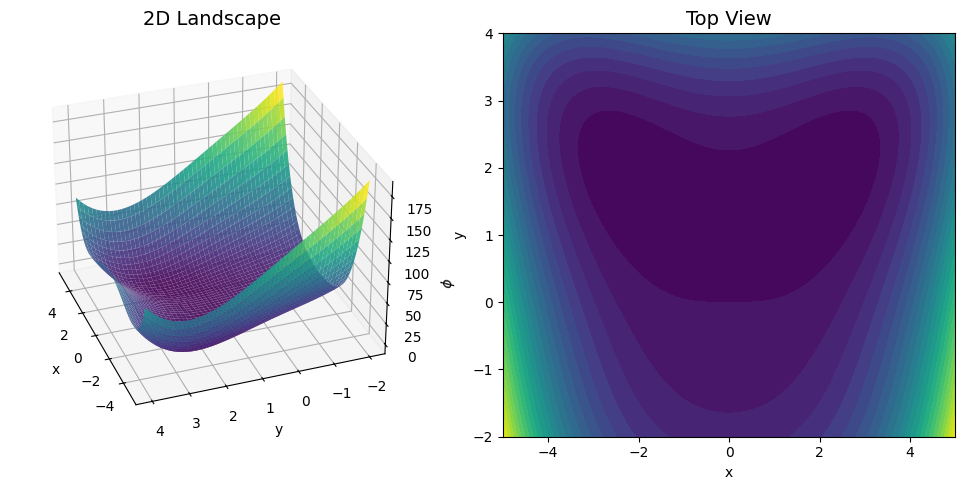

Simulating 1000 particles for 200 steps...


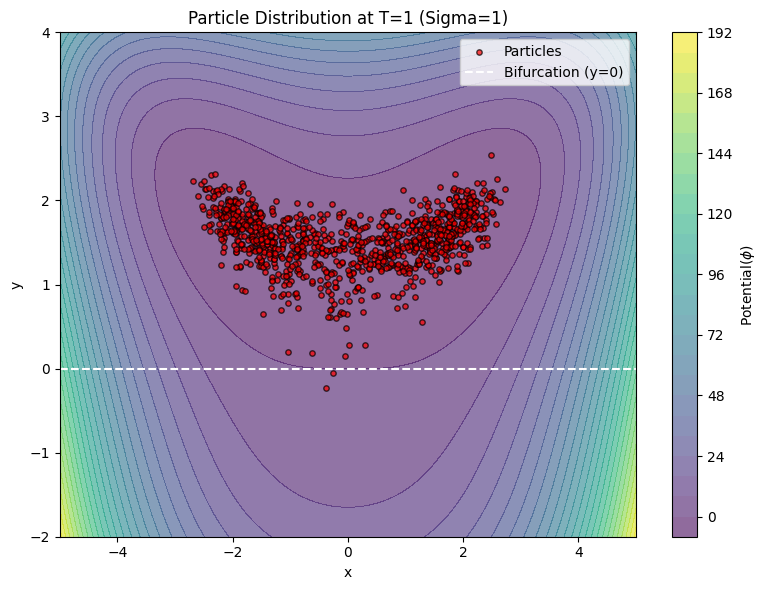

In [6]:
import jax
import jax.numpy as jnp
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import cm
import optax

PARAMS2 = {
    'a': -0.877,      
    'b': -1.2,    
    'c': 2.08,      
    'd': -1.4     
}

PARAMS = {
    'a': 0,      # Bifurcation point (y=0)
    'b': -1.6,   # x-scale stability, distance between branches^-1
    'c': 3.5,      # Drive strength (tilt), distance between bifurcation and new stable points
    'd': -1.2     # Wall steepness
}

# Simulation controls
N_PARTICLES = 1000
T_TOTAL = 1          # Total duration
dt = 0.005            # Time step size
n_steps = int(T_TOTAL / dt)
sigma = 1          # Noise
x0 = 0.0             # Initial x position (near the unstable point)
dx = 0.1            # Initial noise scale for x
y0 = -1.0            # Initial y position (before bifurcation)
dy = 0.1            # Initial noise scale for y

# --- JAX Random Setup & Initialization ---
# JAX requires explicit PRNG keys for reproducibility
key = jax.random.PRNGKey(4)
key, subkey_x, subkey_y = jax.random.split(key, 3)

# initialize particles using jax.random
particles_x = x0 + dx * jax.random.normal(subkey_x, (N_PARTICLES,))
particles_y = y0 + dy * jax.random.normal(subkey_y, (N_PARTICLES,))

def potential(x, y, p):
    """ H= -(y - a)x^2 + e^b x^4 - c y + e^d y^4 """
    return -(y - p['a']) * (x**2) + jnp.exp(p['b']) * (x**4) - p['c'] * y + jnp.exp(p['d']) * (y**4)

# --- JAX Autodiff ---
# jax.grad calculates derivatives w.r.t x (arg 0) and y (arg 1)
# jax.vmap vectorizes this calculation to handle arrays of particles
force_fn = jax.vmap(jax.grad(potential, argnums=(0, 1)), in_axes=(0, 0, None))

def force(x, y, p):
    """
    Fx = -dH/dx, Fy = -dH/dy
    Now calculated automatically via JAX autodiff!
    """
    grad_x, grad_y = force_fn(x, y, p)
    return -grad_x, -grad_y

# --- Plot Setup ---

# Using jnp.linspace; matplotlib handles JAX arrays seamlessly
x = jnp.linspace(-5, 5, 200)
y = jnp.linspace(-2, 4, 200)
X, Y = jnp.meshgrid(x, y)
Z = potential(X, Y, p=PARAMS)

# --- Plotting ---

fig = plt.figure(figsize=(10, 5))

# Subplot 1: 3D Surface Plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.9, edgecolor='none')
ax1.set_title("2D Landscape", fontsize=14)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("$\phi$")
# Adjust view angle to see the branching clearly
ax1.view_init(elev=30, azim=160) 

# Subplot 2: Contour Plot (Top-down view)
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contourf(X, Y, Z, levels=30, cmap=cm.viridis)
ax2.set_title("Top View", fontsize=14)
ax2.set_xlabel("x")
ax2.set_ylabel("y")

plt.tight_layout()
plt.show()

# --- Run Simulation (Euler-Maruyama) ---

# We isolate the physics update into a function so jax can JIT compile it
@jax.jit
def update_step(px, py, step_key, params, dt_val, sigma_val):
    # Calculate deterministic force (Drift)
    fx, fy = force(px, py, params)
    
    # Generate random noise (Diffusion)
    # Scale by sqrt(dt) strictly according to SDE theory
    key_x, key_y = jax.random.split(step_key)
    noise_x = jax.random.normal(key_x, px.shape) * jnp.sqrt(dt_val)
    noise_y = jax.random.normal(key_y, py.shape) * jnp.sqrt(dt_val)
    
    # Update positions (Note: JAX arrays are immutable, so we return new ones)
    new_px = px + fx * dt_val + sigma_val * noise_x
    new_py = py + fy * dt_val + sigma_val * noise_y
    
    return new_px, new_py

print(f"Simulating {N_PARTICLES} particles for {n_steps} steps...")

for step in range(n_steps):
    # Split the key at every step to ensure completely new random noise
    key, step_key = jax.random.split(key)
    particles_x, particles_y = update_step(particles_x, particles_y, step_key, PARAMS, dt, sigma)

# --- Visualization ---

plt.figure(figsize=(8, 6))

# Plot the Landscape Contour
contour = plt.contourf(X, Y, Z, levels=25, cmap='viridis', alpha=0.6)
plt.colorbar(contour, label='Potential($\phi$)')

# Plot the Particles
plt.scatter(particles_x, particles_y, color='red', s=15, alpha=0.7, edgecolors='black', label='Particles')

# Mark the bifurcation line
plt.axhline(PARAMS['a'], color='white', linestyle='--', label='Bifurcation (y=0)')

plt.title(f"Particle Distribution at T={T_TOTAL} (Sigma={sigma})")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
import ipywidgets as widgets  # Import the Jupyter-native widgets
from IPython.display import display

# --- Initialization (JAX style) ---
# Assuming 'key' is carried over from Part 1. We split it to get fresh randomness.
key, subkey_x, subkey_y, scan_key = jax.random.split(key, 4)

p_x = x0 + dx * jax.random.normal(subkey_x, (N_PARTICLES,))
p_y = y0 + dy * jax.random.normal(subkey_y, (N_PARTICLES,))


# --- JAX lax.scan for history generation ---
# Instead of a Python for loop and np.zeros arrays, we use jax.lax.scan.
# It carries the state forward and automatically accumulates the history.

@jax.jit
def scan_step(carry, step_key):
    """
    carry: A tuple of the current state (px, py)
    step_key: A unique random key for this specific time step
    """
    px, py = carry
    
    # Calculate deterministic force (Drift)
    fx, fy = force(px, py, PARAMS)
    
    # Generate random noise (Diffusion)
    key_x, key_y = jax.random.split(step_key)
    noise_x = jax.random.normal(key_x, px.shape) * jnp.sqrt(dt)
    noise_y = jax.random.normal(key_y, py.shape) * jnp.sqrt(dt)
    
    # Update positions
    new_px = px + fx * dt + sigma * noise_x
    new_py = py + fy * dt + sigma * noise_y
    
    # Return (new_carry_state, output_to_save_to_history)
    # We save the *current* px, py to history, and carry the *new* px, py forward
    return (new_px, new_py), (px, py)

# Generate an array of unique keys for each step in the loop
step_keys = jax.random.split(scan_key, n_steps)

# Run the compiled scan loop
# history will be a tuple of (history_x, history_y), automatically stacked along a new time dimension
_, (history_x, history_y) = jax.lax.scan(scan_step, (p_x, p_y), step_keys)


# --- Visualization with Interactive Slider ---

def plot_frame(step_index):
    
    # Create a figure
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot Background
    ax.contourf(X, Y, Z, levels=25, cmap='viridis', alpha=0.6)
    ax.axhline(PARAMS['a'], color='white', linestyle='--', alpha=0.5, label='Bifurcation')
    
    # Plot Particles
    current_x = history_x[step_index]
    current_y = history_y[step_index]
    ax.scatter(current_x, current_y, c='red', s=15, edgecolors='black', alpha=0.8)
    
    # Labels
    ax.set_title(f"Time: {step_index * dt:.2f} / {T_TOTAL:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    
    plt.show() 

# 1. Create the interactive widget object
ui = widgets.interactive(
    plot_frame, 
    step_index=widgets.IntSlider(
        min=0, 
        max=n_steps-1, 
        step=5,           
        value=0, 
        description='Time Step',
        continuous_update=False # Prevents lagging while dragging
    )
)

# 2. Display the UI object explicitly
display(ui)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Step', max=199, step=5), O…

In [ ]:
# MMD Parameter Inference

# 1. Generate Fake "Real Cell Data" (Target)
target_params = PARAMS.copy()

# Create a master key for inference
infer_key = jax.random.PRNGKey(23)
infer_key, target_key = jax.random.split(infer_key)

def get_sim_data_jax(params, key, steps):
    # Setup initial positions
    k1, k2, scan_key = jax.random.split(key, 3)
    px = x0 + dx * jax.random.normal(k1, (N_PARTICLES,))
    py = y0 + dy * jax.random.normal(k2, (N_PARTICLES,))
    
    # We use scan but only care about the final state, so we discard history
    def step_fn(carry, step_key):
        curr_px, curr_py = carry
        # force is the JAX-vmap-grad function from Part 1
        fx, fy = force(curr_px, curr_py, params)
        
        kx, ky = jax.random.split(step_key)
        n_x = jax.random.normal(kx, curr_px.shape) * jnp.sqrt(dt)
        n_y = jax.random.normal(ky, curr_py.shape) * jnp.sqrt(dt)
        
        new_px = curr_px + fx * dt + sigma * n_x
        new_py = curr_py + fy * dt + sigma * n_y
        
        # Return new state as carry, None for history
        return (new_px, new_py), None
        
    step_keys = jax.random.split(scan_key, steps)
    final_state, _ = jax.lax.scan(step_fn, (px, py), step_keys)
    
    # Stack into Shape: (N, 2)
    return jnp.column_stack(final_state)

# We pass the function as the first argument, and set the 3rd argument (index 2) as static.
get_sim_data_jax = jax.jit(get_sim_data_jax, static_argnums=(2,))

# Generate Target Data
target_data = get_sim_data_jax(target_params, target_key, n_steps)


# 2. Compact MMD Loss Function (multiple bandwidths for stability)
@jax.jit
def mmd_loss(x1, x2):
    """
    Calculates MMD squared: E[K(x,x)] + E[K(y,y)] - 2E[K(x,y)]
    """
    def k_mean(a, b):
        # 1. Expand dims for broadcasting: (N, 1, 2) - (1, M, 2)
        diff = a[:, None, :] - b[None, :, :]
        # 2. Squared Euclidean distance
        dist_sq = jnp.sum(diff**2, axis=-1)
        # 3. Gaussian Kernel & Mean
        return jnp.exp(-dist_sq / (2*0.01)).mean()+jnp.exp(-dist_sq / (2*1)).mean()+jnp.exp(-dist_sq / (2*100)).mean()

    # MMD Formula
    return k_mean(x1, x1) + k_mean(x2, x2) - 2 * k_mean(x1, x2)


# 2b. Wasserstein Distance (Sliced) Loss Function
@jax.jit
def wasserstein_loss(x1, x2):
    """
    Calculates Sliced Wasserstein Distance between two point clouds.
    Uses random projections to approximate the full Wasserstein distance efficiently.
    """
    n_projections = 50
    rng_key = jax.random.PRNGKey(0)
    
    def single_projection_distance(key):
        # Generate random direction on unit circle
        theta = jax.random.uniform(key, minval=0, maxval=2*jnp.pi)
        direction = jnp.array([jnp.cos(theta), jnp.sin(theta)])
        
        # Project both point clouds onto this direction
        proj_x1 = jnp.dot(x1, direction)
        proj_x2 = jnp.dot(x2, direction)
        
        # Sort projections
        proj_x1_sorted = jnp.sort(proj_x1)
        proj_x2_sorted = jnp.sort(proj_x2)
        
        # Compute 1D Wasserstein distance (L2 between sorted points)
        return jnp.mean((proj_x1_sorted - proj_x2_sorted) ** 2)
    
    # Average over random projections
    keys = jax.random.split(rng_key, n_projections)
    distances = jax.vmap(single_projection_distance)(keys)
    
    return jnp.mean(distances)


# 3. Objective Function for Automatic Differentiation

def objective(params, fixed_params, target, key):
    """
    This function isolates what we want to optimize (params) 
    from what remains constant (fixed_params).
    """
    # Merge parameters for the simulation
    full_params = {**fixed_params, **params}
    
    # Run simulation
    sim_data = get_sim_data_jax(full_params, key, n_steps)
    
    # Calculate MMD loss against target
    return mmd_loss(sim_data, target)

# This creates a function that computes both the loss and the gradients 
loss_and_grad_fn = jax.jit(jax.value_and_grad(objective, argnums=0))


# 4. Run Gradient Descent

# We separate the parameters we want to learn from the fixed ones.
# Ensure initial values are floats.
current_params = {'a': 0.9, 'b': -1.2, 'c': 2.1, 'd': -1.4} 
fixed_params = {}


In [9]:
# Learning Rate
lr_a = 1
lr_b = 1
lr_c = 3
lr_d = 1

print(f"Target a: {target_params['a']}, Start a: {current_params['a']}")
print(f"Target b: {target_params['b']}, Start b: {current_params['b']}")
print(f"Target c: {target_params['c']}, Start c: {current_params['c']}")
print(f"Target d: {target_params['d']}, Start d: {current_params['d']}")

# use a fixed seed for the optimization forward passes so the gradients are not overwhelmed by noise
opt_key = jax.random.PRNGKey(49)

for i in range(500): 
    
    # 1. Get Loss and EXACT Gradients in one step
    loss, grads = loss_and_grad_fn(current_params, fixed_params, target_data, opt_key)
    
    # Extract gradients 
    # JAX returns a dictionary of gradients with exactly the same keys as current_params
    grad_a = grads['a']
    grad_b = grads['b']
    grad_c = grads['c']
    grad_d = grads['d']
    
    # 2. Update
    current_params['a'] -= lr_a * grad_a
    current_params['b'] -= lr_b * grad_b
    current_params['c'] -= lr_c * grad_c
    current_params['d'] -= lr_d * grad_d

    # Apply physical constraints(no restriction on a; restriction on b should be tuned carefully 
    # if b is too small, particles will not be restricted enough and can diverge to infinity)
    if current_params['c'] < 0.001:
        current_params['c'] = 0.001

    # Cutoff condition
    if loss < 0.0001:
        break
    
    print(f"Iter {i}: Loss={loss:.5f}")
    print(f"    Grad a={grad_a:.4f} -> Update a to {current_params['a']:.3f}")
    print(f"    Grad b={grad_b:.4f} -> Update b to {current_params['b']:.3f}")
    print(f"    Grad c={grad_c:.4f} -> Update c to {current_params['c']:.3f}")
    print(f"    Grad d={grad_d:.4f} -> Update d to {current_params['d']:.3f}")

print(f"Final Estimated a: {current_params['a']:.3f} (True: {target_params['a']})")
print(f"Final Estimated b: {current_params['b']:.3f} (True: {target_params['b']})")
print(f"Final Estimated c: {current_params['c']:.3f} (True: {target_params['c']})")
print(f"Final Estimated d: {current_params['d']:.3f} (True: {target_params['d']})")

Target a: 0, Start a: 0.9
Target b: -1.6, Start b: -1.2
Target c: 3.5, Start c: 2.1
Target d: -1.2, Start d: -1.4
Iter 0: Loss=0.21637
    Grad a=0.1402 -> Update a to 0.760
    Grad b=0.0598 -> Update b to -1.260
    Grad c=-0.1322 -> Update c to 2.497
    Grad d=0.0957 -> Update d to -1.496
Iter 1: Loss=0.13899
    Grad a=0.1569 -> Update a to 0.603
    Grad b=0.0730 -> Update b to -1.333
    Grad c=-0.0877 -> Update c to 2.760
    Grad d=0.0834 -> Update d to -1.579
Iter 2: Loss=0.08334
    Grad a=0.1562 -> Update a to 0.447
    Grad b=0.0779 -> Update b to -1.411
    Grad c=-0.0583 -> Update c to 2.935
    Grad d=0.0569 -> Update d to -1.636
Iter 3: Loss=0.04440
    Grad a=0.1313 -> Update a to 0.315
    Grad b=0.0682 -> Update b to -1.479
    Grad c=-0.0319 -> Update c to 3.030
    Grad d=0.0227 -> Update d to -1.659
Iter 4: Loss=0.02336
    Grad a=0.0906 -> Update a to 0.225
    Grad b=0.0488 -> Update b to -1.528
    Grad c=-0.0107 -> Update c to 3.062
    Grad d=-0.0054 -> Upda

In [10]:
# 1. Initialize the Adam optimizer
# Only need one base learning rate now. Adam automatically scales the actual rate based on their historical gradient variance.
base_learning_rate = 0.1
optimizer = optax.adam(learning_rate=base_learning_rate)

# 2. Initialize the optimizer state
# Optax is pure functional. It does not store state internally. 
# We must explicitly create and pass the 'opt_state' which holds the momentum and variance trackers for our specific parameters.
opt_state = optimizer.init(current_params)

# Fixed seed for the optimization forward passes to isolate parameter gradients from SDE noise
opt_key = jax.random.PRNGKey(42)

for i in range(1000): 
    
    # Calculate Loss and EXACT Gradients
    loss, grads = loss_and_grad_fn(current_params, fixed_params, target_data, opt_key)
    
    # 3. Calculate updates using Optax
    # We pass the raw gradients and the current optimizer state. 
    # Optax returns the mathematically scaled updates and a newly updated state.
    updates, opt_state = optimizer.update(grads, opt_state)
    
    # 4. Apply updates to the parameters
    # This replaces the manual `current_params['c'] -= lr * grad_c`
    current_params = optax.apply_updates(current_params, updates)

    # 5. Apply physical constraints
    # JAX arrays require jnp.maximum instead of Python's built-in max()
    current_params['c'] = jnp.maximum(current_params['c'], 0.001)

    # Cutoff condition
    if loss < 0.0001:
        break
    
    # We use float() or .item() to format JAX arrays into standard Python floats for printing
    print(f"Iter {i}: Loss={loss:.5f}")
    print(f"    Grad a={grads['a']:.4f} -> Update a to {float(current_params['a']):.3f}")
    print(f"    Grad b={grads['b']:.4f} -> Update b to {float(current_params['b']):.3f}")
    print(f"    Grad c={grads['c']:.4f} -> Update c to {float(current_params['c']):.3f}")
    print(f"    Grad d={grads['d']:.4f} -> Update d to {float(current_params['d']):.3f}")

print(f"Final Estimated a: {float(current_params['a']):.3f} (True: {target_params['a']})")
print(f"Final Estimated b: {float(current_params['b']):.3f} (True: {target_params['b']})")
print(f"Final Estimated c: {float(current_params['c']):.3f} (True: {target_params['c']})")
print(f"Final Estimated d: {float(current_params['d']):.3f} (True: {target_params['d']})")

Iter 0: Loss=0.00302
    Grad a=0.0187 -> Update a to -0.069
    Grad b=0.0091 -> Update b to -1.719
    Grad c=-0.0063 -> Update c to 3.382
    Grad d=0.0087 -> Update d to -1.362
Iter 1: Loss=0.01148
    Grad a=-0.0799 -> Update a to -0.011
    Grad b=-0.0488 -> Update b to -1.659
    Grad c=0.0290 -> Update c to 3.324
    Grad d=-0.0464 -> Update d to -1.301
Iter 2: Loss=0.00346
    Grad a=-0.0244 -> Update a to 0.049
    Grad b=-0.0162 -> Update b to -1.594
    Grad c=0.0090 -> Update c to 3.262
    Grad d=-0.0146 -> Update d to -1.238
Iter 3: Loss=0.00446
    Grad a=0.0376 -> Update a to 0.071
    Grad b=0.0203 -> Update b to -1.566
    Grad c=-0.0133 -> Update c to 3.238
    Grad d=0.0201 -> Update d to -1.211
Iter 4: Loss=0.00730
    Grad a=0.0554 -> Update a to 0.060
    Grad b=0.0310 -> Update b to -1.571
    Grad c=-0.0201 -> Update c to 3.249
    Grad d=0.0319 -> Update d to -1.220
Iter 5: Loss=0.00606
    Grad a=0.0486 -> Update a to 0.029
    Grad b=0.0272 -> Update b to -